##Exploratory Data Analysis(EDA) & Business Intelligence

###Objective
#####The objective of this analysis is to identify patterns, trends, and relationships within the sales dataset. The analysis includes descriptive statistics, business-oriented SQL queries, multivariate analysis, and dashboard planning to support data-driven decision making.

In [ ]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading Dataset
df = pd.read_excel('/content/ApexPlanet_DataAnalytics_Dataset.xlsx')
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [ ]:
#Checking for missing values
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [ ]:
#Descriptive Statistics
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
#Category Distribution
df['Category'].value_counts()

,count
Category,
Electronics,354
Education,178
Furniture,159
Fashion,156
Grocery,153


###Handling Null Values


In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)

/tmp/ipykernel_1468/340939523.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1468/340939523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
#Verification
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


###Univariate Analysis

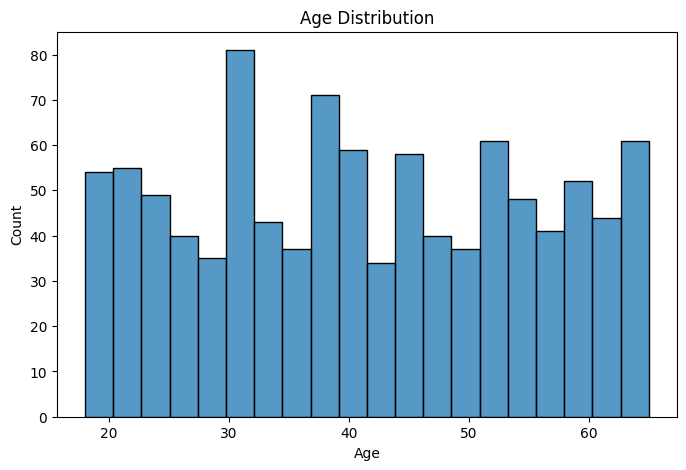

In [ ]:
#Age Distributionn
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution')
plt.show()

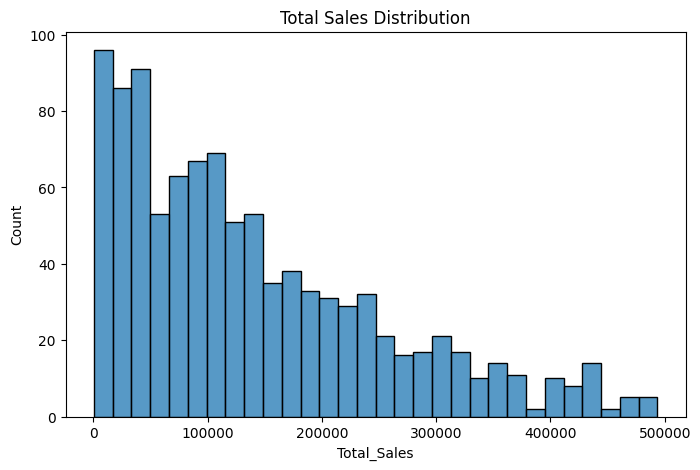

In [ ]:
#Total Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Sales'], bins=30)
plt.title('Total Sales Distribution')
plt.show()

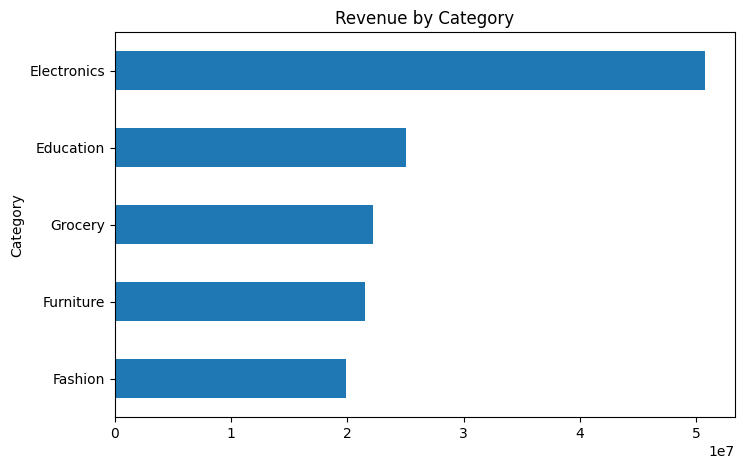

In [ ]:
#Sales By Category
sales_category = df.groupby('Category')['Total_Sales'].sum()

sales_category.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Revenue by Category')
plt.show()

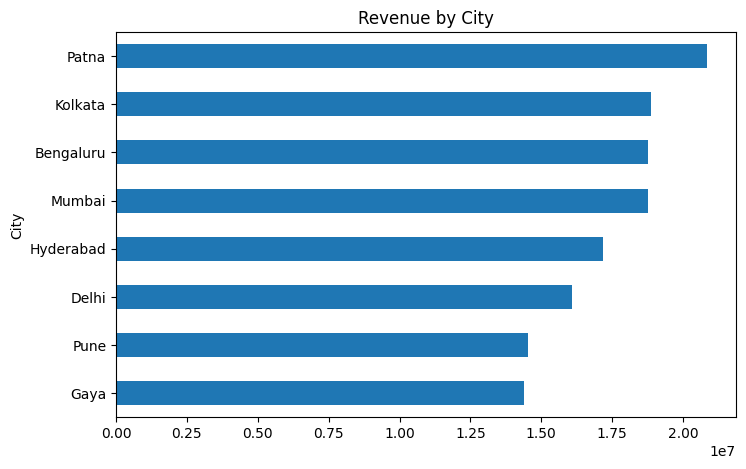

In [ ]:
#Sales by City
city_sales = df.groupby('City')['Total_Sales'].sum()

city_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Revenue by City')
plt.show()

###Multivariate Analysis

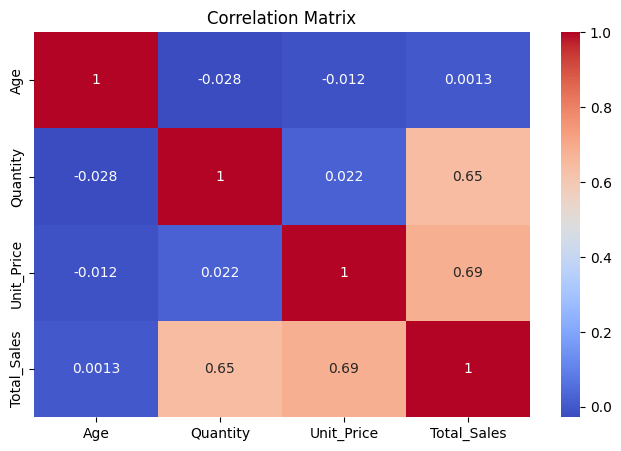

In [ ]:
#Correlation Matrix
corr = df[['Age',
           'Quantity',
           'Unit_Price',
           'Total_Sales']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

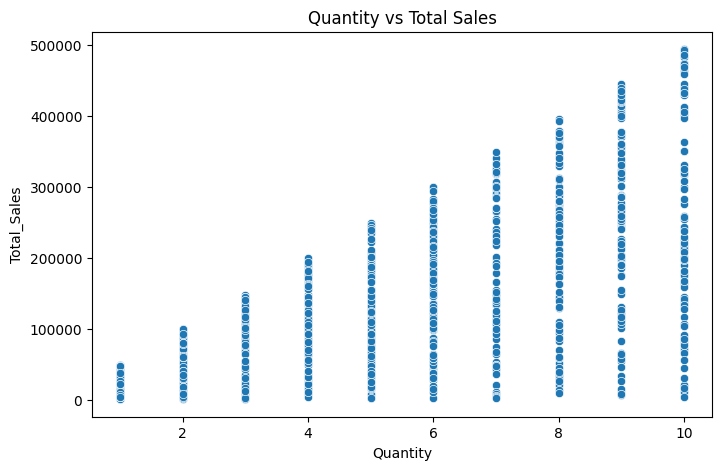

In [ ]:
#Quantity vs Total Sales
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total_Sales'
)

plt.title('Quantity vs Total Sales')
plt.show()

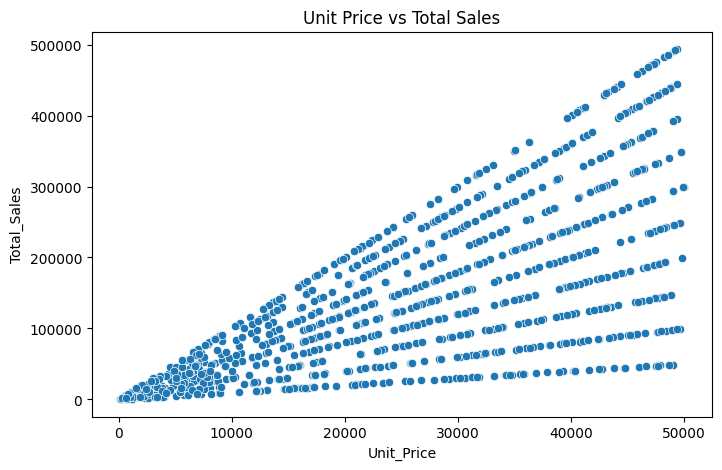

In [ ]:
#Unit Price vs Total Sales
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Unit_Price',
    y='Total_Sales'
)

plt.title('Unit Price vs Total Sales')
plt.show()

###Business Intelligence

In [ ]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

1000

####1. Top 5 Products by Revenue

In [ ]:
query = """
SELECT Product,
       ROUND(SUM(Total_Sales),2) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


####2.Revenue by Category

In [ ]:
query = """
SELECT Category,
       ROUND(SUM(Total_Sales),2) AS Revenue
FROM sales
GROUP BY Category
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,Category,Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


####3. Revenue by City

In [ ]:
query = """
SELECT City,
       ROUND(SUM(Total_Sales),2) AS Revenue
FROM sales
GROUP BY City
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,City,Revenue
0,Patna,20826584.43
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39


####4. Revenue by Gender

In [ ]:
query = """
SELECT Gender,
       ROUND(SUM(Total_Sales),2) AS Revenue
FROM sales
GROUP BY Gender;
"""

pd.read_sql(query, conn)

,Gender,Revenue
0,Female,66935889.02
1,Male,72463550.63


####5. Average Sales per Category

In [ ]:
query = """
SELECT Category,
       ROUND(AVG(Total_Sales),2) AS Avg_Sales
FROM sales
GROUP BY Category
ORDER BY Avg_Sales DESC;
"""

pd.read_sql(query, conn)

,Category,Avg_Sales
0,Grocery,145305.30
1,Electronics,143442.32
2,Education,140627.47
3,Furniture,135355.73
4,Fashion,127153.18


####6. Monthly Sales Trend

In [ ]:
query = """
SELECT strftime('%m', Order_Date) AS Month,
       ROUND(SUM(Total_Sales),2) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,Revenue
0,01,10905580.72
1,02,11511181.46
2,03,13059899.94
3,04,12222700.17
4,05,10984689.25
5,06,12912332.64
6,07,11746226.80
7,08,9448471.22
8,09,9179896.29
9,10,12500936.50


###Key Insights
######Electronics is the highest-performing category.
######Laptop is the top revenue-generating product.
######Patna generates the highest city-level revenue.
######March records the strongest monthly sales.
######Quantity and Unit Price are major drivers of Total Sales.
######Customer age has minimal impact on purchasing behavior.